In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(51717, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list       

In [4]:
df = df.drop(columns=['url', 'address', 'phone', 'menu_item', 'reviews_list', 'dish_liked'])

df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

df = df.dropna(subset=['rate', 'location', 'rest_type', 'cuisines'])

df = df.drop_duplicates()

print(df.shape)
print(df.isnull().sum())

(41430, 11)
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                         0
rest_type                        0
cuisines                         0
approx_cost(for two people)    240
listed_in(type)                  0
listed_in(city)                  0
dtype: int64


In [5]:
df = df.dropna(subset=['approx_cost(for two people)'])
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [6]:
print(df.describe())
print(df['rate'].mean(), df['rate'].median())

               rate         votes  approx_cost(for two people)
count  41190.000000  41190.000000                 41190.000000
mean       3.701731    352.066715                   603.545909
std        0.439929    883.461453                   464.651174
min        1.800000      0.000000                    40.000000
25%        3.400000     21.000000                   300.000000
50%        3.700000     73.000000                   500.000000
75%        4.000000    277.000000                   750.000000
max        4.900000  16832.000000                  6000.000000
3.701731002670551 3.7


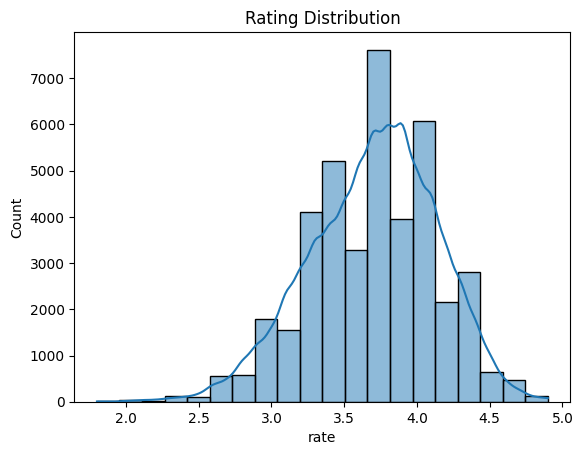

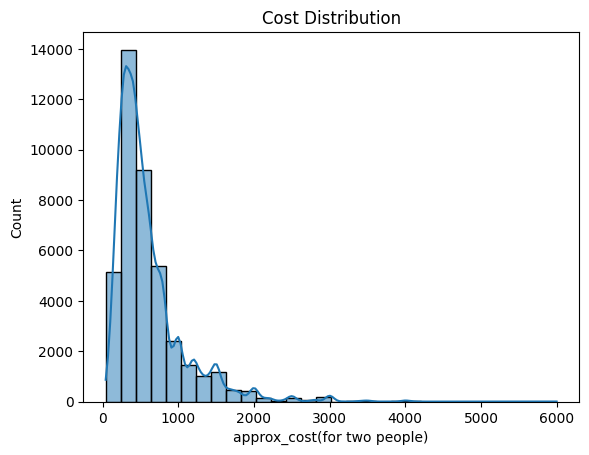

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['rate'], bins=20, kde=True)
plt.title('Rating Distribution')
plt.show()

sns.histplot(df['approx_cost(for two people)'], bins=30, kde=True)
plt.title('Cost Distribution')
plt.show()

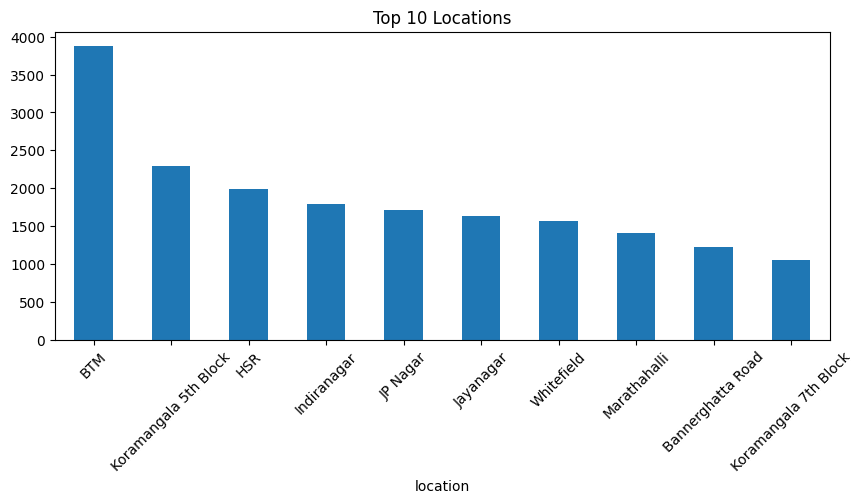

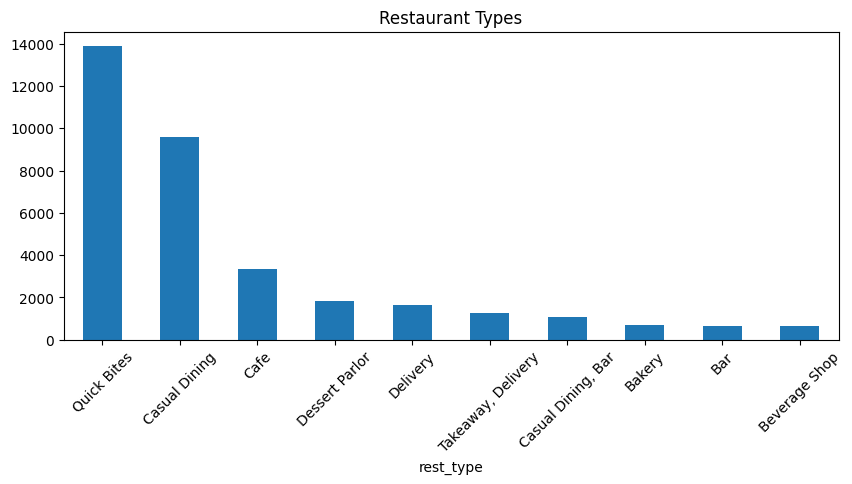

In [8]:
df['location'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title('Top 10 Locations')
plt.xticks(rotation=45)
plt.show()

df['rest_type'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title('Restaurant Types')
plt.xticks(rotation=45)
plt.show()

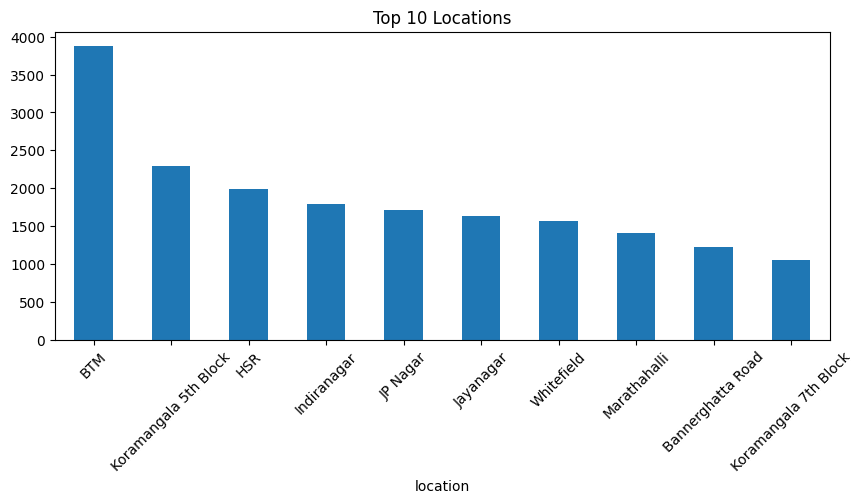

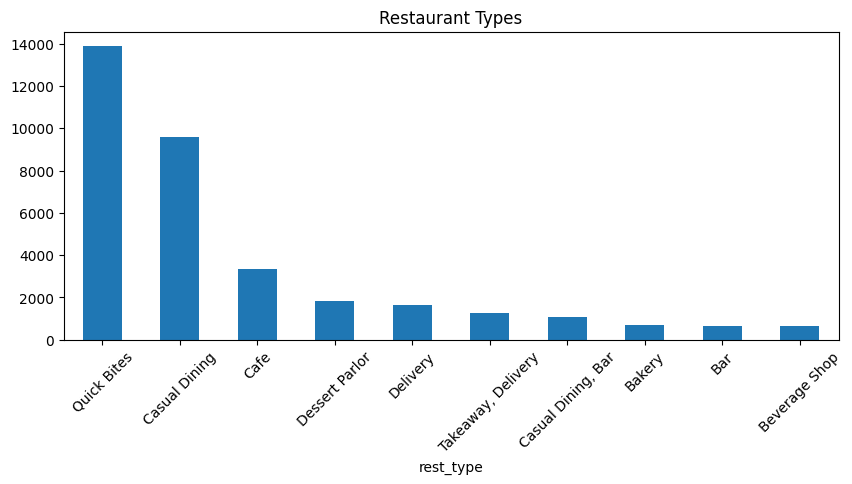

In [9]:
df['location'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title('Top 10 Locations')
plt.xticks(rotation=45)
plt.show()

df['rest_type'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title('Restaurant Types')
plt.xticks(rotation=45)
plt.show()

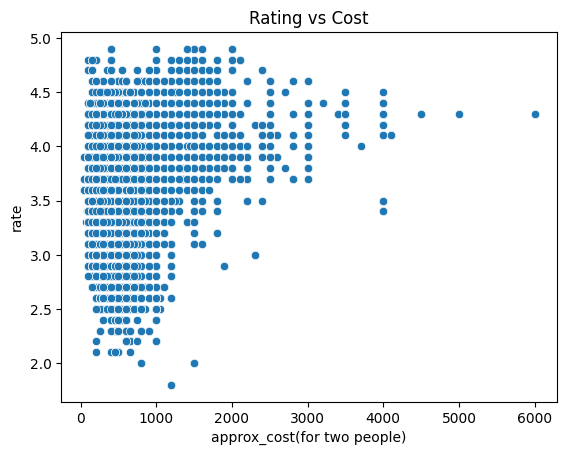

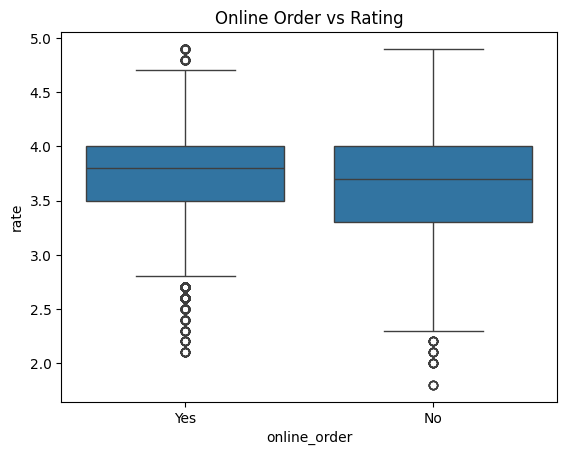

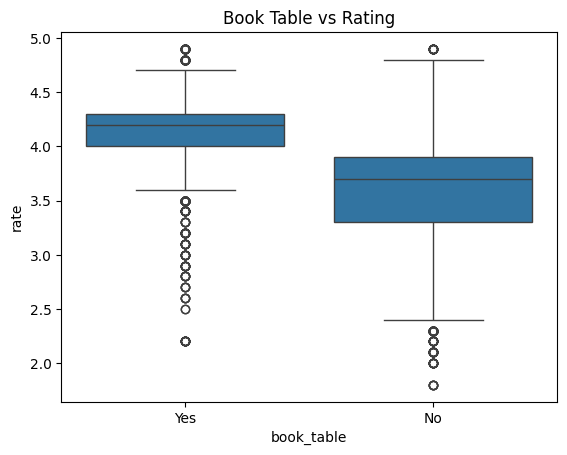

In [10]:
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title('Rating vs Cost')
plt.show()

sns.boxplot(x='online_order', y='rate', data=df)
plt.title('Online Order vs Rating')
plt.show()

sns.boxplot(x='book_table', y='rate', data=df)
plt.title('Book Table vs Rating')
plt.show()

In [11]:
top = df.sort_values('votes', ascending=False).head(10)[['name', 'votes', 'rate', 'location']]
print(top)

                              name  votes  rate               location
49170  Byg Brewski Brewing Company  16832   4.9          Sarjapur Road
49627  Byg Brewski Brewing Company  16832   4.9          Sarjapur Road
50059  Byg Brewski Brewing Company  16832   4.9          Sarjapur Road
3921   Byg Brewski Brewing Company  16345   4.9          Sarjapur Road
4801   Byg Brewski Brewing Company  16345   4.9          Sarjapur Road
4944   Byg Brewski Brewing Company  16345   4.9          Sarjapur Road
19268                         Toit  14956   4.7            Indiranagar
18643                         Toit  14956   4.7            Indiranagar
36668                     Truffles  14726   4.7  Koramangala 5th Block
34779                     Truffles  14723   4.7  Koramangala 5th Block


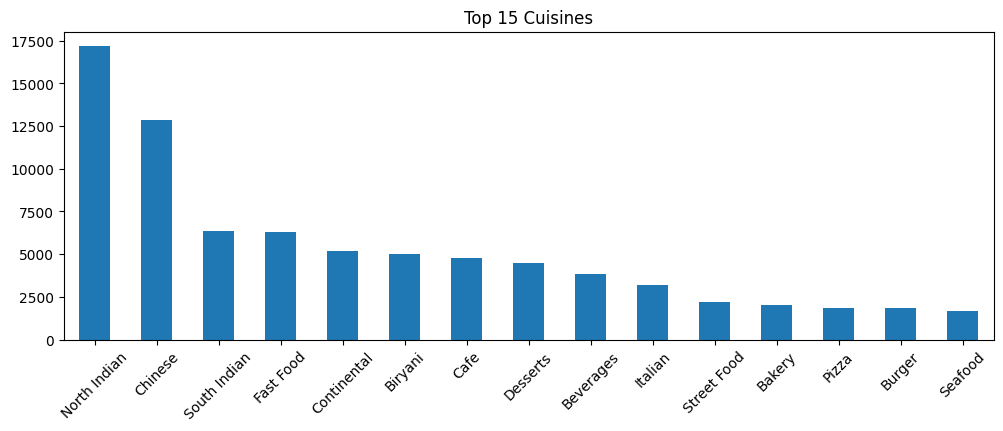

In [12]:
from collections import Counter

cuisine_list = df['cuisines'].str.split(',').explode().str.strip()
top_cuisines = pd.Series(Counter(cuisine_list)).sort_values(ascending=False).head(15)

top_cuisines.plot(kind='bar', figsize=(12,4))
plt.title('Top 15 Cuisines')
plt.xticks(rotation=45)
plt.show()